##1. Imports

In [8]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pre-processing and pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA

# Model selection and evaluation metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

SEED=42;
TARGET='covid_vaccine';
ID='respondent_id'

##2. Loading Data

In [9]:
train=pd.read_csv('dataset_C_training.csv')
y=train[TARGET].values
print('train',train.shape)
train.head()

train (4756, 31)


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


##3. Exploratory Data Analysis

- Target Balance

Class counts: {0: 3202, 1: 1554}
Positive rate: 0.327


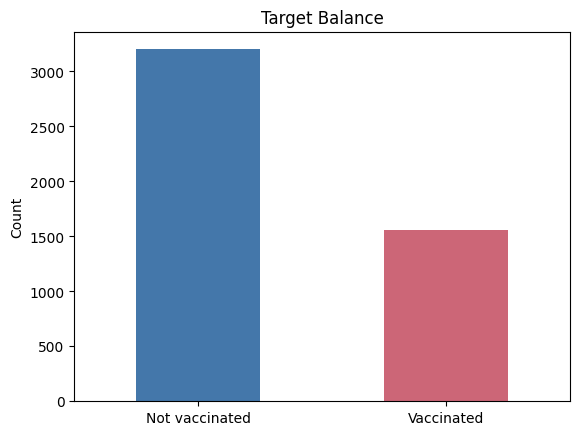

In [13]:
# Get the exact counts and the positive rate
target_counts = pd.Series(y).value_counts()
positive_rate = y.mean()

# Print the counts and the positive rate
print(f"Class counts: {target_counts.to_dict()}")
print(f"Positive rate: {positive_rate:.3f}")

# Plot the balance of the target variable using the hex colors
target_counts.sort_index().plot(kind='bar', color=['#4477aa', '#cc6677'])

# Add labels and title to the chart
plt.xticks([0, 1], ['Not vaccinated', 'Vaccinated'], rotation=0)
plt.ylabel('Count')
plt.title('Target Balance')

# Display the plot
plt.show()

- Missing Values

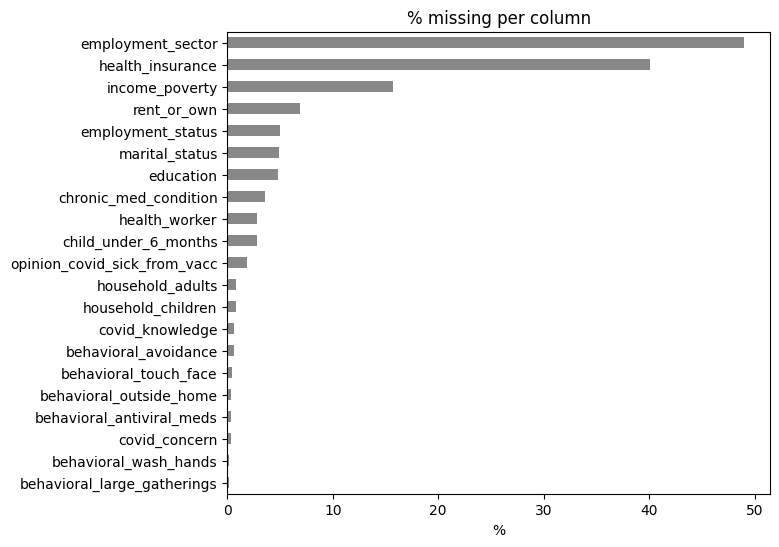

In [14]:
# Calculate the percentage of missing values for each column
missing_pct = (train.isna().mean() * 100).round(1)

# Keep only the columns that actually have missing data and sort them
missing_pct = missing_pct[missing_pct > 0].sort_values()

# Create a horizontal bar chart
missing_pct.plot(kind='barh', figsize=(7, 6), color='#888')

# Add title and x-axis label
plt.title('% missing per column')
plt.xlabel('%')

# Display the plot
plt.show()

**3.3 Correlation Heatmap**

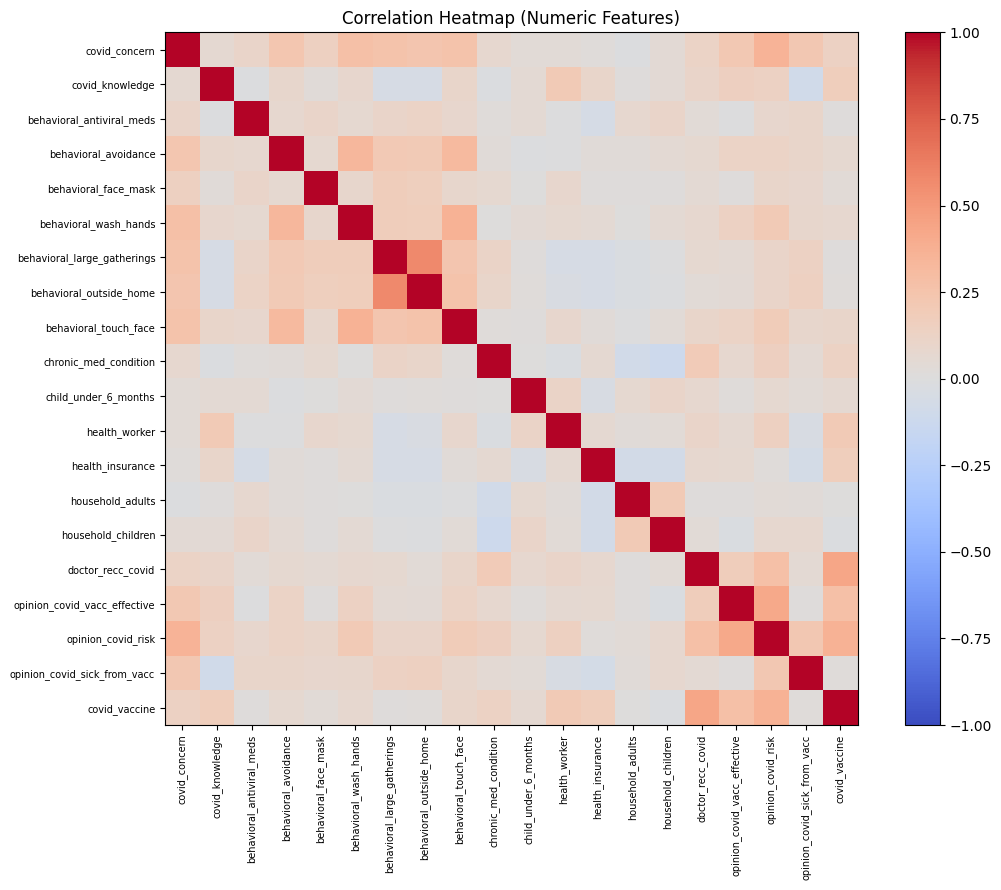

In [15]:
# Select numeric columns and ignore the ID column so it doesn't skew the heatmap
numeric_data = train.select_dtypes(include='number').drop(columns=['respondent_id'], errors='ignore')

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))

# Plot the heatmap (blue to red scale from -1 to 1)
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Set the ticks to match the number of columns
ax.set_xticks(range(len(correlation_matrix)))
ax.set_yticks(range(len(correlation_matrix)))

# Add the column names as labels, rotating the x-axis ones to fit
ax.set_xticklabels(correlation_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(correlation_matrix.columns, fontsize=7)

# Add a colorbar legend to the side
fig.colorbar(im, fraction=0.046)

# Add title and adjust layout so labels don't get cut off
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()

# Display the plot
plt.show()

**3.4 Strongest Predictors of Vaccination**

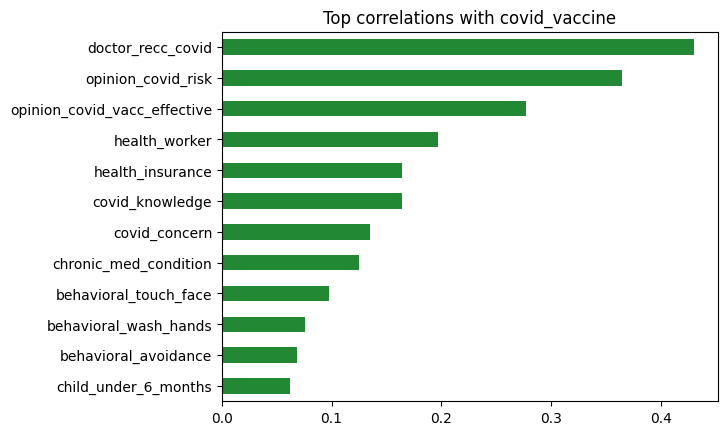

doctor_recc_covid               0.430
opinion_covid_risk              0.365
opinion_covid_vacc_effective    0.277
health_worker                   0.197
health_insurance                0.165
covid_knowledge                 0.164
covid_concern                   0.135
chronic_med_condition           0.125
behavioral_touch_face           0.097
behavioral_wash_hands           0.075
behavioral_avoidance            0.068
child_under_6_months            0.062
Name: covid_vaccine, dtype: float64


In [16]:
# Define our target variable
target_col = 'covid_vaccine'

# Get correlations just for our target, and drop the target itself (to hide the 1.0 self-correlation)
top_correlations = correlation_matrix[target_col].drop(target_col)

# Sort by absolute value to find the strongest positive AND negative relationships
# Then, keep only the top 12 most important features
top_correlations = top_correlations.sort_values(key=abs, ascending=False).head(12)

# Plot as a horizontal bar chart (sort normally here so the largest bar is at the top of the graph)
top_correlations.sort_values().plot(kind='barh', color='#228833')

# Add a title
plt.title('Top correlations with covid_vaccine')
plt.show()

# Print the actual correlation values rounded to 3 decimal places
print(top_correlations.round(3))